# Sentinel-1 Preprocessing and LiDAR Collocation

This notebook processes extracted Sentinel-1 SAFE products and cuts windows corresponding to existing LiDAR patches. It supports VV and VH polarizations, converts calibrated values to dB for model input, and writes `s1_patch_<id>/t<i>.tif` directories.

The raw SAFE route below performs calibration and GCP-based warping, but it is **not full radiometric terrain correction**. For production work, use externally terrain-corrected GeoTIFFs from SNAP, ASF HyP3, or an equivalent processor.

In [2]:
from pathlib import Path
import glob
import json
import xml.etree.ElementTree as ET
import numpy as np
import rasterio
from rasterio.windows import Window, from_bounds
from rasterio.warp import transform_bounds, calculate_default_transform, reproject, Resampling
from scipy.interpolate import RectBivariateSpline
import matplotlib.pyplot as plt

In [8]:
REPO_DIR = Path('/cs/student/project_msc/2025/aibh/jiayiche')
REGION = 'tuk'
LIDAR_DIR = REPO_DIR / 'input_data' / 'lidar_patches_tuk_tessa'
SAFE_ROOT = REPO_DIR / 'raw_data' / f'{REGION}_sentinel1_downloads'
CORRECTED_DIR = REPO_DIR / 'raw_data' / f'{REGION}_sentinel1_corrected'
DIY_DIR = REPO_DIR / 'raw_data' / f'{REGION}_sentinel1_diy_corrected'
OUT_DIR = REPO_DIR / 'input_data' / 's1_patches_tuk_tessa'
USE_CORRECTED_GEOTIFFS = False
DST_RESOLUTION_M = 10.0
OUT_DIR.mkdir(parents=True, exist_ok=True)


## Calibration helpers for raw SAFE products

Sentinel-1 calibration XML provides a sparse sigma-nought lookup grid. The grid is interpolated to measurement resolution, then the calibrated raster is warped using the product GCPs.

In [4]:
def find_pol_files(safe_dir, pol):
    measurement = next(Path(safe_dir).glob(f'measurement/*-{pol}-*.tiff'))
    calibration = next(Path(safe_dir).glob(f'annotation/calibration/calibration-*-{pol}-*.xml'))
    return measurement, calibration

def calibration_lut(xml_path, shape):
    root = ET.parse(xml_path).getroot()
    vectors = root.find('calibrationVectorList').findall('calibrationVector')
    lines, pixels, values = [], None, []
    for vector in vectors:
        lines.append(int(vector.find('line').text))
        current_pixels = np.array([int(x) for x in vector.find('pixel').text.split()], dtype=float)
        pixels = current_pixels if pixels is None else pixels
        values.append([float(x) for x in vector.find('sigmaNought').text.split()])
    interpolator = RectBivariateSpline(np.asarray(lines, float), pixels, np.asarray(values, float), kx=1, ky=1)
    return interpolator(np.arange(shape[0]), np.arange(shape[1])).astype(np.float32)

def warp_grid(measurement_path, dst_crs, resolution):
    with rasterio.open(measurement_path) as src:
        gcps, gcp_crs = src.gcps
        transform, width, height = calculate_default_transform(gcp_crs, dst_crs, src.width, src.height, gcps=gcps, resolution=(resolution, resolution))
    return transform, width, height, gcp_crs

def calibrate_and_warp(measurement_path, calibration_path, dst_crs, output_path, grid):
    transform, width, height, gcp_crs = grid
    with rasterio.open(measurement_path) as src:
        dn = src.read(1).astype(np.float32)
        gcps, _ = src.gcps
    lut = calibration_lut(calibration_path, dn.shape)
    with np.errstate(divide='ignore', invalid='ignore'):
        sigma0 = np.where(lut > 0, (dn ** 2) / (lut ** 2), np.nan).astype(np.float32)
    profile = {'driver': 'GTiff', 'dtype': 'float32', 'count': 1, 'width': width, 'height': height, 'crs': dst_crs, 'transform': transform, 'nodata': np.nan, 'compress': 'deflate'}
    with rasterio.open(output_path, 'w', **profile) as dst:
        reproject(sigma0, rasterio.band(dst, 1), gcps=gcps, src_crs=gcp_crs, dst_transform=transform, dst_crs=dst_crs, resampling=Resampling.bilinear, src_nodata=np.nan, dst_nodata=np.nan)
    return output_path

In [5]:
safe_dirs = sorted(SAFE_ROOT.glob('*/**/*.SAFE'))
print('SAFE dirs found:', len(safe_dirs))

lidar_ref = next(LIDAR_DIR.glob('lidar_patch_*.tif'))
with rasterio.open(lidar_ref) as ref:
    dst_crs = ref.crs
print('dst_crs:', dst_crs)

vv, vv_xml = find_pol_files(safe_dirs[0], 'vv')
with rasterio.open(vv) as src:
    print('Source width/height:', src.width, src.height)
    gcps, gcp_crs = src.gcps
    print('Number of GCPs:', len(gcps))
    print('GCP CRS:', gcp_crs)
    print('GCP lon range:', min(g.x for g in gcps), max(g.x for g in gcps))
    print('GCP lat range:', min(g.y for g in gcps), max(g.y for g in gcps))
    src_width, src_height = src.width, src.height

transform, width, height = calculate_default_transform(
    gcp_crs, dst_crs, src_width, src_height, gcps=gcps, resolution=(10.0, 10.0)
)
print('Computed output width/height:', width, height)
print('Expected pixel count (millions):', width * height / 1e6)
print('Transform:', transform)


SAFE dirs found: 8
dst_crs: EPSG:6931
Source width/height: 26449 16330
Number of GCPs: 210
GCP CRS: EPSG:4326
GCP lon range: -139.5039083741496 -131.81235776777444
GCP lat range: 68.87943564270302 70.85408554826724
Computed output width/height: 28389 31128
Expected pixel count (millions): 883.692792
Transform: | 10.00, 0.00,-1704797.57|
| 0.00,-10.00, 1750676.97|
| 0.00, 0.00, 1.00|


## Build analysis-ready Sentinel-1 products

For each product, VV and VH are warped onto the same grid and stacked as bands 1 and 2. If corrected GeoTIFFs already exist, set `USE_CORRECTED_GEOTIFFS = True`.

In [6]:
def build_products():
    if USE_CORRECTED_GEOTIFFS:
        return sorted(CORRECTED_DIR.glob('*.tif'))
    safe_dirs = sorted(SAFE_ROOT.glob('*/**/*.SAFE'))
    lidar_ref = next(LIDAR_DIR.glob('lidar_patch_*.tif'))
    with rasterio.open(lidar_ref) as ref:
        dst_crs = ref.crs
    paths = []
    DIY_DIR.mkdir(parents=True, exist_ok=True)
    for index, safe_dir in enumerate(safe_dirs):
        vv, vv_xml = find_pol_files(safe_dir, 'vv')
        vh, vh_xml = find_pol_files(safe_dir, 'vh')
        grid = warp_grid(vv, dst_crs, DST_RESOLUTION_M)
        vv_out = DIY_DIR / f'_vv_{index}.tif'
        vh_out = DIY_DIR / f'_vh_{index}.tif'
        calibrate_and_warp(vv, vv_xml, dst_crs, vv_out, grid)
        calibrate_and_warp(vh, vh_xml, dst_crs, vh_out, grid)
        final = DIY_DIR / f't{index}.tif'
        with rasterio.open(vv_out) as a, rasterio.open(vh_out) as b:
            meta = a.meta.copy(); meta.update(count=2)
            with rasterio.open(final, 'w', **meta) as dst:
                dst.write(a.read(1), 1); dst.write(b.read(1), 2)
        vv_out.unlink(); vh_out.unlink(); paths.append(final)
    return paths

products = build_products()
print('Analysis-ready products:', [str(p) for p in products])

Analysis-ready products: ['/cs/student/project_msc/2025/aibh/jiayiche/raw_data/tuk_sentinel1_diy_corrected/t0.tif', '/cs/student/project_msc/2025/aibh/jiayiche/raw_data/tuk_sentinel1_diy_corrected/t1.tif', '/cs/student/project_msc/2025/aibh/jiayiche/raw_data/tuk_sentinel1_diy_corrected/t2.tif', '/cs/student/project_msc/2025/aibh/jiayiche/raw_data/tuk_sentinel1_diy_corrected/t3.tif', '/cs/student/project_msc/2025/aibh/jiayiche/raw_data/tuk_sentinel1_diy_corrected/t4.tif', '/cs/student/project_msc/2025/aibh/jiayiche/raw_data/tuk_sentinel1_diy_corrected/t5.tif', '/cs/student/project_msc/2025/aibh/jiayiche/raw_data/tuk_sentinel1_diy_corrected/t6.tif', '/cs/student/project_msc/2025/aibh/jiayiche/raw_data/tuk_sentinel1_diy_corrected/t7.tif']


In [7]:
import rasterio
import numpy as np

for p in products:
    with rasterio.open(p) as src:
        vv = src.read(1)
        vh = src.read(2)
        print(p.name if hasattr(p, 'name') else p)
        print('  shape:', src.shape, 'count:', src.count, 'dtype:', src.dtypes, 'crs:', src.crs)
        for name, band in [('VV', vv), ('VH', vh)]:
            valid = np.isfinite(band) & (band != 0)
            print(f'  {name}: min={np.nanmin(band):.3f} max={np.nanmax(band):.3f} '
                  f'mean={np.nanmean(band):.3f} nonzero_frac={valid.mean():.3f}')


t0.tif
  shape: (31128, 28389) count: 2 dtype: ('float32', 'float32') crs: EPSG:6931
  VV: min=0.000 max=8.932 mean=0.022 nonzero_frac=0.449
  VH: min=0.000 max=1.045 mean=0.005 nonzero_frac=0.449
t1.tif
  shape: (31088, 27207) count: 2 dtype: ('float32', 'float32') crs: EPSG:6931
  VV: min=0.000 max=23.066 mean=0.020 nonzero_frac=0.463
  VH: min=0.000 max=1.188 mean=0.004 nonzero_frac=0.463
t2.tif
  shape: (31086, 27206) count: 2 dtype: ('float32', 'float32') crs: EPSG:6931
  VV: min=0.000 max=24.372 mean=0.034 nonzero_frac=0.462
  VH: min=0.000 max=0.714 mean=0.004 nonzero_frac=0.462
t3.tif
  shape: (31083, 27195) count: 2 dtype: ('float32', 'float32') crs: EPSG:6931
  VV: min=0.000 max=38.538 mean=0.026 nonzero_frac=0.463
  VH: min=0.000 max=0.919 mean=0.004 nonzero_frac=0.463
t4.tif
  shape: (31133, 28398) count: 2 dtype: ('float32', 'float32') crs: EPSG:6931
  VV: min=0.000 max=7.080 mean=0.022 nonzero_frac=0.449
  VH: min=0.000 max=1.738 mean=0.004 nonzero_frac=0.449
t5.tif
  sha

## Match products to LiDAR patches

The Sentinel-1 window is selected from each LiDAR patch's georeferenced bounds. The output keeps the temporal naming convention used by Tessa's loader. For the later model notebook, VV and VH are converted to dB and adapted to the four-channel conditioning interface.

In [9]:
def collocate(products, lidar_dir, output_dir, resolution=10.0):
    for lidar_path in sorted(Path(lidar_dir).glob('lidar_patch_*.tif')):
        patch_id = lidar_path.stem.split('_')[-1]
        with rasterio.open(lidar_path) as lidar:
            bounds, lidar_crs = lidar.bounds, lidar.crs
        patch_dir = Path(output_dir) / f's1_patch_{patch_id}'
        patch_dir.mkdir(parents=True, exist_ok=True)
        attrs = []
        for i, product_path in enumerate(products):
            with rasterio.open(product_path) as src:
                sb = transform_bounds(lidar_crs, src.crs, *bounds, densify_pts=21)
                window = from_bounds(*sb, transform=src.transform).round_offsets().round_lengths()
                patch = src.read(window=window)
                profile = src.profile.copy(); profile.update(height=patch.shape[1], width=patch.shape[2], transform=rasterio.windows.transform(window, src.transform), count=patch.shape[0], dtype='float32', nodata=np.nan)
            if patch.shape[1] == 0 or patch.shape[2] == 0 or not np.isfinite(patch).any():
                continue
            with rasterio.open(patch_dir / f't{i}.tif', 'w', **profile) as dst:
                dst.write(patch.astype(np.float32))
            attrs.append({'source': str(product_path), 'polarizations': ['VV', 'VH'], 'acquisition_date': None, 'cloud_cover': 0.0})
        with (patch_dir / 'attrs.json').open('w') as handle:
            json.dump(attrs, handle, indent=2)

collocate(products, LIDAR_DIR, OUT_DIR, DST_RESOLUTION_M)
print('Collocation complete:', OUT_DIR)

Collocation complete: /cs/student/project_msc/2025/aibh/jiayiche/input_data/s1_patches_tuk_tessa


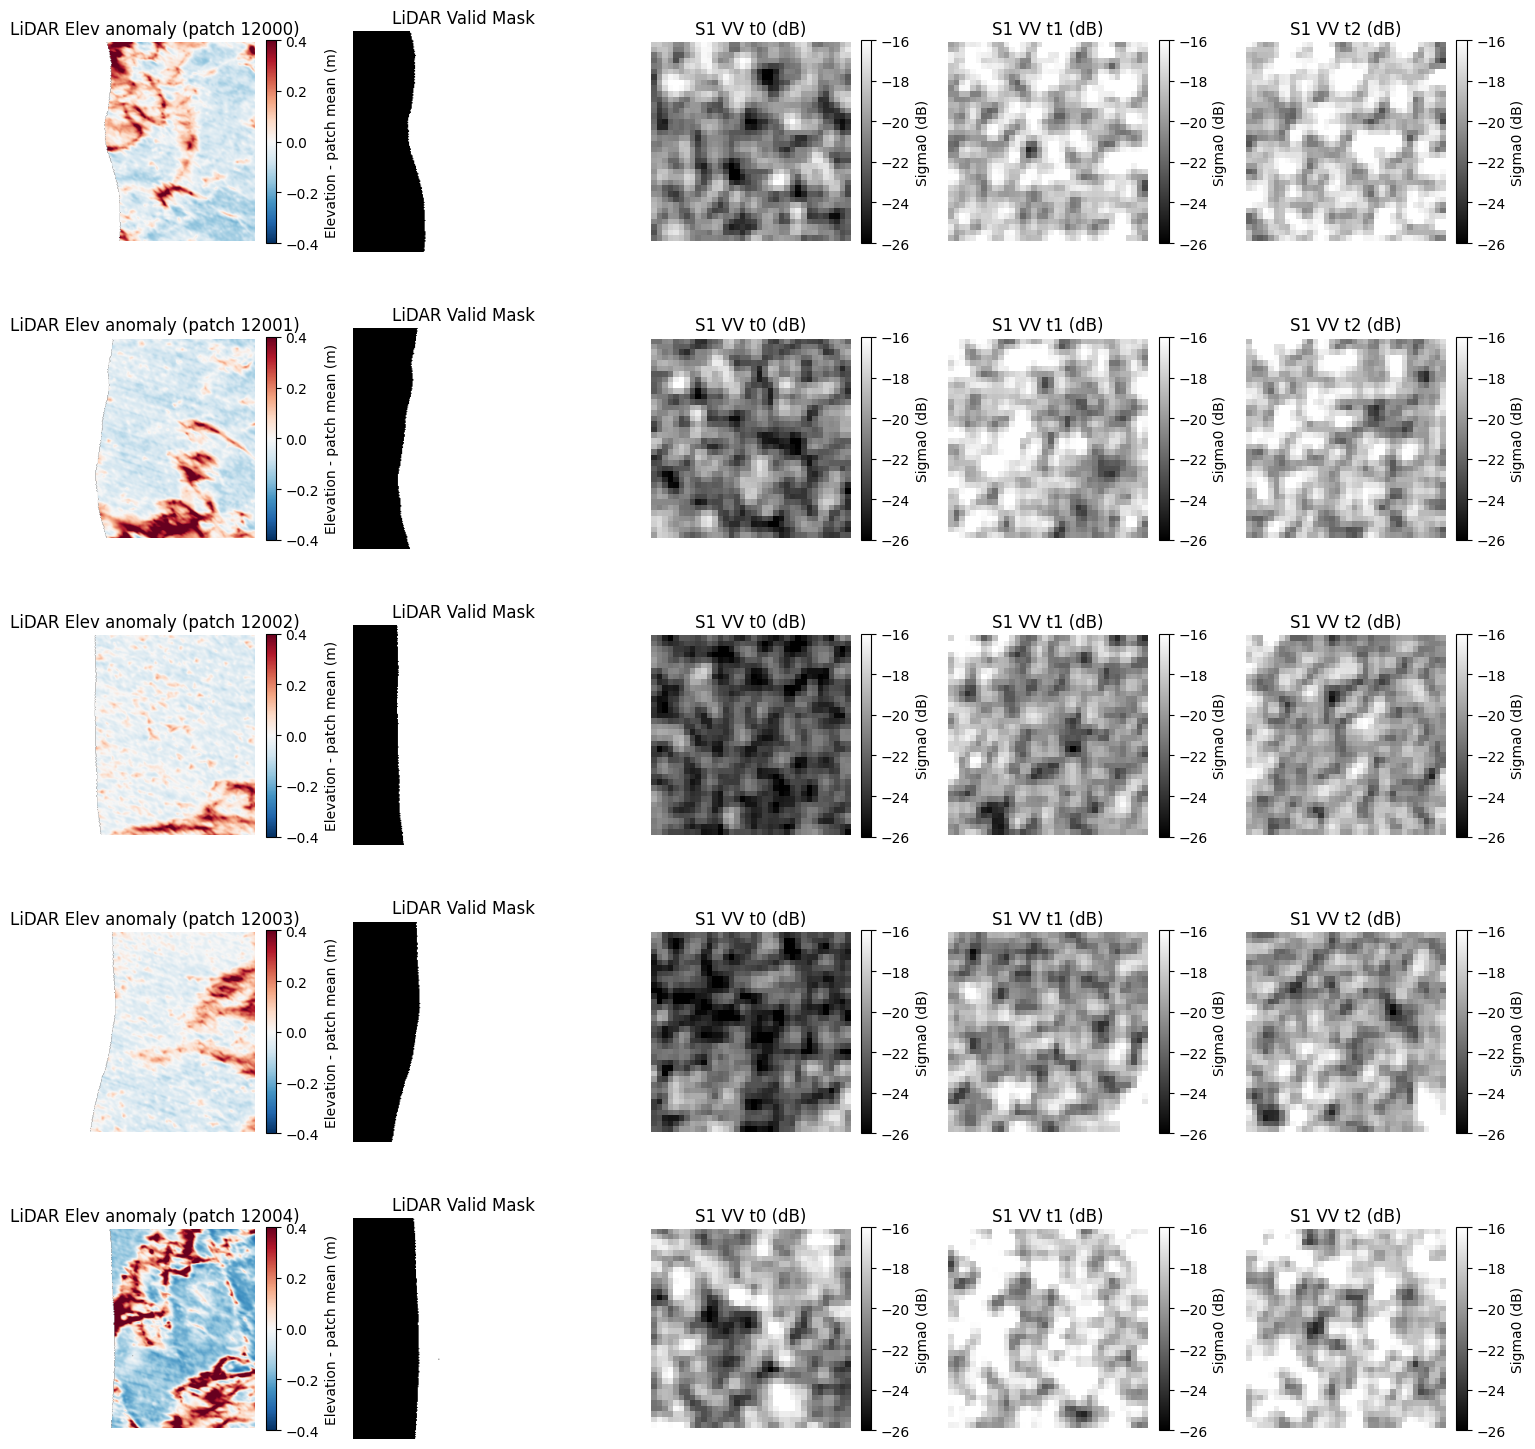

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from pathlib import Path

LIDAR_DIR_VIZ = Path('/cs/student/project_msc/2025/aibh/jiayiche/input_data/lidar_patches_tuk_tessa')
S1_DIR_VIZ = Path('/cs/student/project_msc/2025/aibh/jiayiche/input_data/s1_patches_tuk_tessa')

def to_db(sigma0, floor=1e-6):
    return 10 * np.log10(np.clip(sigma0, floor, None))

def plot_patch_comparison(patch_ids, n_timesteps=3, band='VV'):
    n_rows = len(patch_ids)
    n_cols = 2 + n_timesteps
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
    if n_rows == 1:
        axes = axes[None, :]
    band_idx = 0 if band == 'VV' else 1

    for row, patch_id in enumerate(patch_ids):
        with rasterio.open(LIDAR_DIR_VIZ / f'lidar_patch_{patch_id}.tif') as src:
            elev, mask = src.read(1), src.read(2)
        valid = mask > 0
        elev_anom = np.where(valid, elev - elev[valid].mean(), np.nan)

        ax = axes[row, 0]
        im = ax.imshow(elev_anom, cmap='RdBu_r', vmin=-0.4, vmax=0.4)
        ax.set_title(f'LiDAR Elev anomaly (patch {patch_id})')
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, label='Elevation - patch mean (m)')

        ax = axes[row, 1]
        ax.imshow(mask, cmap='gray')
        ax.set_title('LiDAR Valid Mask')
        ax.axis('off')

        patch_dir = S1_DIR_VIZ / f's1_patch_{patch_id}'
        for t in range(n_timesteps):
            ax = axes[row, 2 + t]
            s1_path = patch_dir / f't{t}.tif'
            if s1_path.exists():
                with rasterio.open(s1_path) as src:
                    db = to_db(src.read(band_idx + 1))
                im = ax.imshow(db, cmap='gray', vmin=-26, vmax=-16)
                plt.colorbar(im, ax=ax, fraction=0.046, label='Sigma0 (dB)')
            ax.set_title(f'S1 {band} t{t} (dB)')
            ax.axis('off')

    plt.tight_layout()
    plt.show()

sample_ids = sorted(p.stem.split('_')[-1] for p in LIDAR_DIR_VIZ.glob('lidar_patch_*.tif'))[:5]
plot_patch_comparison(sample_ids, n_timesteps=3, band='VV')


In [15]:
import rasterio
import numpy as np
from pathlib import Path

S1_DIR_CHECK = Path('/cs/student/project_msc/2025/aibh/jiayiche/input_data/s1_patches_tuk_tessa')

fracs = []
partial = 0
total = 0
for patch_dir in sorted(S1_DIR_CHECK.iterdir()):
    for t in range(8):
        f = patch_dir / f't{t}.tif'
        if not f.exists():
            continue
        with rasterio.open(f) as src:
            arr = src.read()
        valid = np.isfinite(arr) & (arr != 0)
        frac = valid.mean()
        fracs.append(frac)
        total += 1
        if frac < 0.999:
            partial += 1

fracs = np.array(fracs)
print(f'Checked {total} patch-timesteps')
print(f'Partial coverage (< 99.9% valid): {partial} ({partial/total:.2%})')
print('Percentiles [0,1,5,25,50,75,95,99,100]:', np.percentile(fracs, [0,1,5,25,50,75,95,99,100]))


Checked 13408 patch-timesteps
Partial coverage (< 99.9% valid): 0 (0.00%)
Percentiles [0,1,5,25,50,75,95,99,100]: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


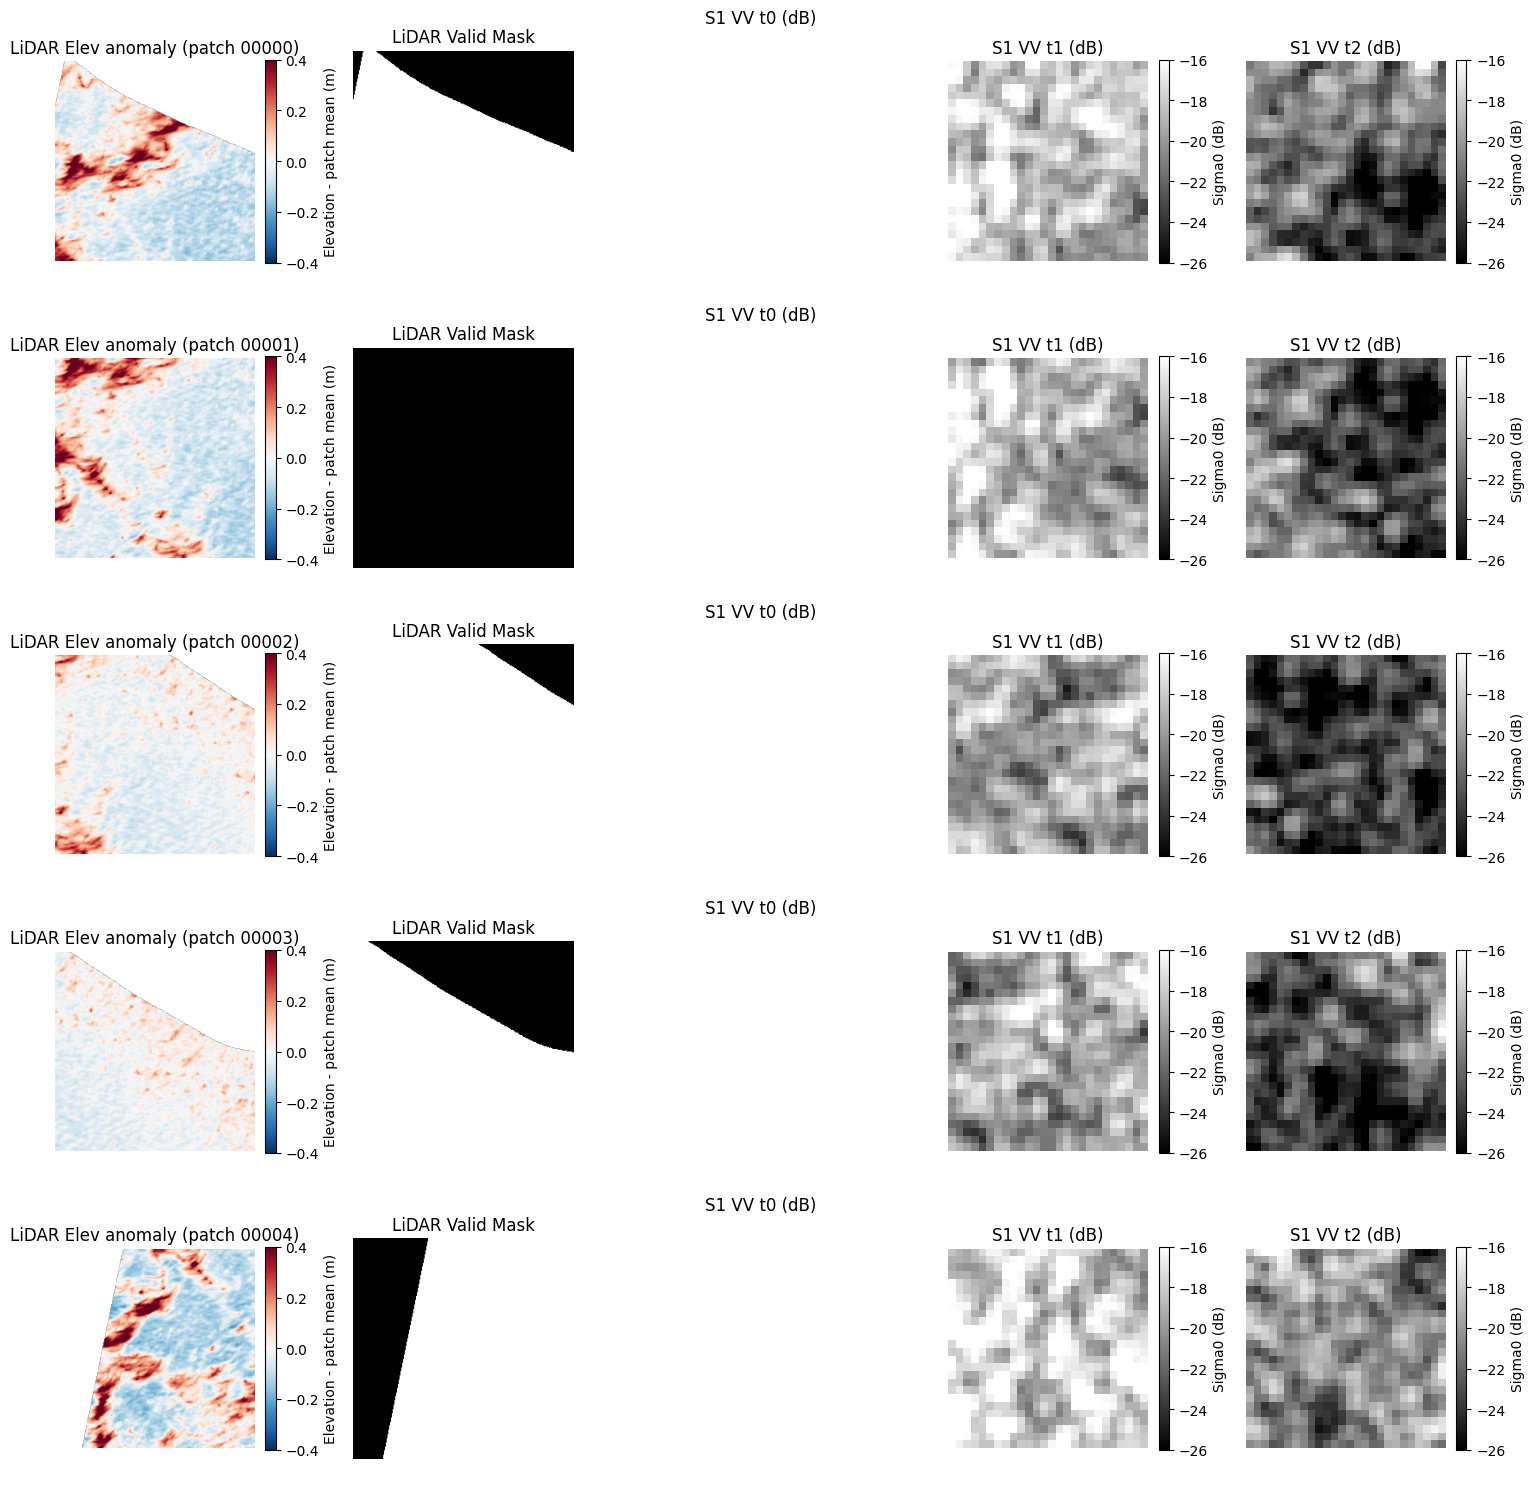

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from pathlib import Path

LIDAR_DIR_VIZ = Path('/cs/student/project_msc/2025/aibh/jiayiche/input_data/lidar_patches_tuk')
S1_DIR_VIZ = Path('/cs/student/project_msc/2025/aibh/jiayiche/input_data/s1_patches_tuk')

def to_db(sigma0, floor=1e-6):
    return 10 * np.log10(np.clip(sigma0, floor, None))

def plot_patch_comparison(patch_ids, n_timesteps=3, band='VV'):
    n_rows = len(patch_ids)
    n_cols = 2 + n_timesteps
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
    if n_rows == 1:
        axes = axes[None, :]
    band_idx = 0 if band == 'VV' else 1

    for row, patch_id in enumerate(patch_ids):
        with rasterio.open(LIDAR_DIR_VIZ / f'lidar_patch_{patch_id}.tif') as src:
            elev, mask = src.read(1), src.read(2)
        valid = mask > 0
        elev_anom = np.where(valid, elev - elev[valid].mean(), np.nan)

        ax = axes[row, 0]
        im = ax.imshow(elev_anom, cmap='RdBu_r', vmin=-0.4, vmax=0.4)
        ax.set_title(f'LiDAR Elev anomaly (patch {patch_id})')
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046, label='Elevation - patch mean (m)')

        ax = axes[row, 1]
        ax.imshow(mask, cmap='gray')
        ax.set_title('LiDAR Valid Mask')
        ax.axis('off')

        patch_dir = S1_DIR_VIZ / f's1_patch_{patch_id}'
        for t in range(n_timesteps):
            ax = axes[row, 2 + t]
            s1_path = patch_dir / f't{t}.tif'
            if s1_path.exists():
                with rasterio.open(s1_path) as src:
                    db = to_db(src.read(band_idx + 1))
                im = ax.imshow(db, cmap='gray', vmin=-26, vmax=-16)
                plt.colorbar(im, ax=ax, fraction=0.046, label='Sigma0 (dB)')
            ax.set_title(f'S1 {band} t{t} (dB)')
            ax.axis('off')

    plt.tight_layout()
    plt.show()

sample_ids = sorted(p.stem.split('_')[-1] for p in LIDAR_DIR_VIZ.glob('lidar_patch_*.tif'))[:5]
plot_patch_comparison(sample_ids, n_timesteps=3, band='VV')
